In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.interpolate as si
import qutip as q
# %matplotlib qt

Approximate cat


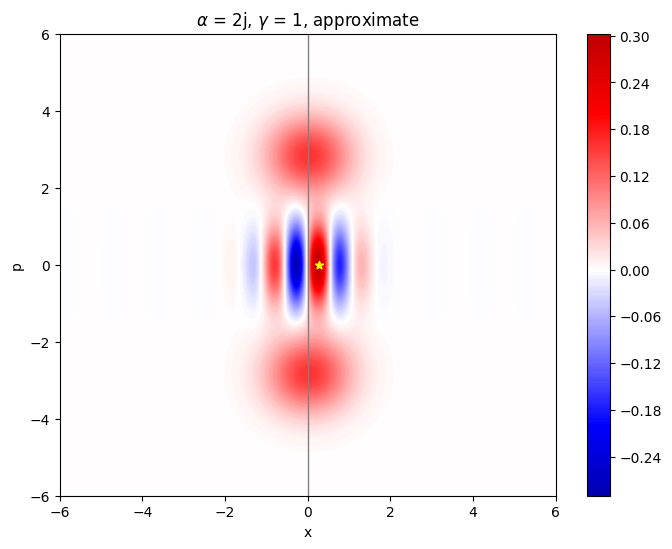

Integration of W 0.9999964799010238
Minus fringe value: -0.288553 at coo (x=-0.279661, y=0.0000)
Plus fringe value: 0.302463 at coo (x=0.254237, y=0.0000)
W(0,0) = 0.029282573130871747
Ideal cat


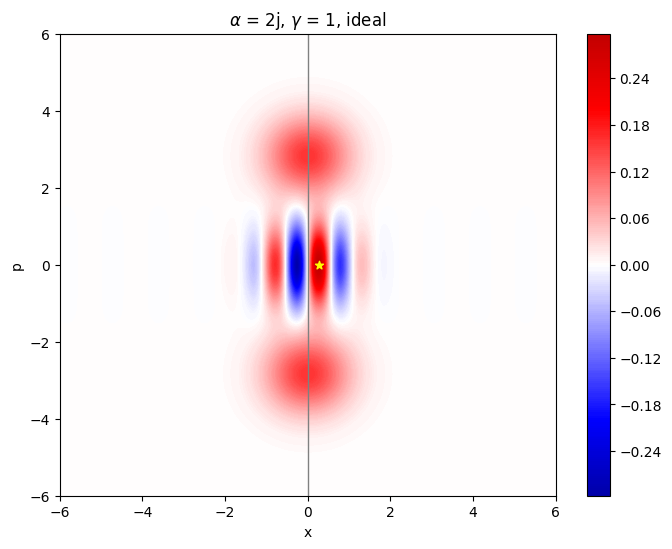

Integration of W 0.999996350863076
Minus fringe value: -0.295666 at coo (x=-0.254237, y=0.0000)
Plus fringe value: 0.295866 at coo (x=0.254237, y=0.0000)
W(0,0) = 0.00010678107090655318


In [2]:
# Figure of Wigner function
xvec =  np.linspace(-6,6,473)
yvec =  np.linspace(-6,6,473)


beta = np.load(f'results/wigner/beta.npy')
alpha = np.load(f'results/wigner/alpha.npy')
gamma = np.load(f'results/wigner/gamma.npy')

# Wigner function of approximate cat
print('Approximate cat')
rho_approx = np.load('results/wigner/rho_approx.npy')

out = q.Qobj(rho_approx)
wig = q.wigner(out,xvec,yvec)

fig0, ax0 = plt.subplots(figsize=(8,6))
cs = ax0.contourf(xvec, yvec, wig, 250,cmap = 'seismic',vmin = -0.4,vmax = 0.4)
ax0.scatter(beta,0, marker = '*',color = 'yellow')
ax0.set(xlabel = 'x',ylabel='p',title =fr'$\alpha$ = {alpha}, $\gamma$ = {gamma}, approximate')
ax0.axvline(x=0.0, color='gray', linestyle='-', linewidth=1)
cbar = fig0.colorbar(cs)
plt.show()
ix = np.argmin(np.abs(xvec - 0.0))
iy = np.argmin(np.abs(yvec - 0.0))

value_at_origin = wig[iy, ix]

# Check of normalization
check = np.trapezoid(np.trapezoid(wig,xvec),yvec)
print('Integration of W',check)

min_idx = np.unravel_index(np.argmin(wig), wig.shape)
max_idx = np.unravel_index(np.argmax(wig), wig.shape)

# Get coordinates
x_min, y_min = xvec[min_idx[1]], yvec[min_idx[0]]
x_max, y_max = xvec[max_idx[1]], yvec[max_idx[0]]
    
print(f"Minus fringe value: {wig[min_idx]:.6f} at coo (x={x_min:.6f}, y={y_min:.4f})")
print(f"Plus fringe value: {wig[max_idx]:.6f} at coo (x={x_max:.6f}, y={y_max:.4f})")
print("W(0,0) =", value_at_origin)


# Wigner function of ideal
print('Ideal cat')
rho_ideal = np.load('results/wigner/rho_ideal.npy')
out = q.Qobj(rho_ideal)
wig = q.wigner(out,xvec,yvec)

fig1, ax1 = plt.subplots(figsize=(8,6))
cs = ax1.contourf(xvec, yvec, wig, 250,cmap = 'seismic',vmin = -0.4,vmax = 0.4)
ax1.set(xlabel = 'x',ylabel='p',title =fr'$\alpha$ = {alpha}, $\gamma$ = {gamma}, ideal')
ax1.scatter(beta,0, marker = '*',color = 'yellow')

ax1.axvline(x=0.0, color='gray', linestyle='-', linewidth=1)
cbar = fig1.colorbar(cs)
plt.show()

ix = np.argmin(np.abs(xvec - 0.0))
iy = np.argmin(np.abs(yvec - 0.0))

value_at_origin = wig[iy, ix]

# Check of normalization
check = np.trapezoid(np.trapezoid(wig,xvec),yvec)
print('Integration of W',check)

min_idx = np.unravel_index(np.argmin(wig), wig.shape)
max_idx = np.unravel_index(np.argmax(wig), wig.shape)

# Get coordinates
x_min, y_min = xvec[min_idx[1]], yvec[min_idx[0]]
x_max, y_max = xvec[max_idx[1]], yvec[max_idx[0]]
    
print(f"Minus fringe value: {wig[min_idx]:.6f} at coo (x={x_min:.6f}, y={y_min:.4f})")
print(f"Plus fringe value: {wig[max_idx]:.6f} at coo (x={x_max:.6f}, y={y_max:.4f})")
print("W(0,0) =", value_at_origin)

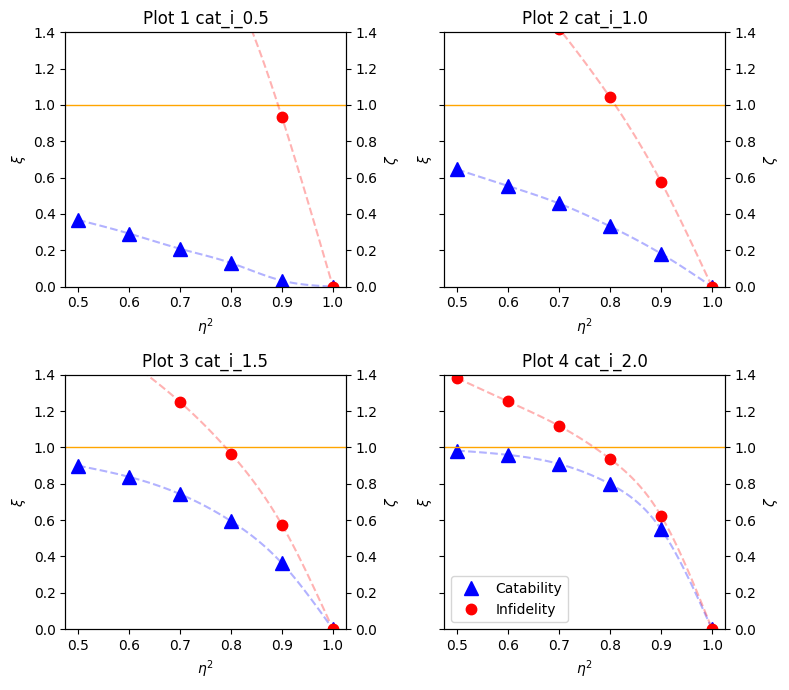

In [3]:
def load_dataset (label):
    return np.load(f'results/comparison/{label}.npy')

tspace = np.load('results/comparison/tspace.npy')

labels = [
    f'cat_i_0.5',f'cat_i_1.0',
    f'cat_i_1.5',f'cat_i_2.0']

fig, axes = plt.subplots(2, 2, figsize = (8, 7),sharey=True)
fig.subplots_adjust(hspace = 0.4, wspace = 0.3)

for i, label in enumerate(labels):

    row = i // 2
    col = i  % 2

    dataset = load_dataset(label)

    x = tspace
    y1 = dataset[:, 0]
    y2 = dataset[:, 1]

    cs1 = si.CubicSpline(x, y1, bc_type = 'natural')
    x_fine1 = np.linspace(min(x), max(x), 100)
    y_fine1 = cs1(x_fine1)

    cs2 = si.CubicSpline(x, y2, bc_type = 'natural')
    x_fine2 = np.linspace(min(x), max(x), 100)
    y_fine2 = cs2(x_fine2)


    axes[row, col].plot(x, y1, "^b", markersize = 10,label =r'Catability')
    axes[row, col].plot(x_fine1, y_fine1, "--b", alpha = 0.3)
    axes[row, col].axhline(y = 1, color="orange", linewidth = 1)
    axes[row, col].set_xlabel(r"$\eta^2$")
    axes[row, col].set_title(f"Plot {i+1} {label}")
    axes[row, col].set_ylabel(r"$\xi$")
    axes[row, col].set_ylim(0.00, 1.4)

    ax2 = axes[row,col].twinx()
    ax2.plot(x, y2, ".r", markersize = 15,label = r'Infidelity')
    ax2.plot(x_fine2, y_fine2, "--r", alpha = 0.3)
    ax2.set_ylabel(r"$\zeta$")
    ax2.set_ylim(0.00, 1.4)
handles1, labels1 = axes[0,0].get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
axes[1,1].legend(handles1 + handles2, labels1 + labels2, loc='lower left')
plt.tight_layout()
plt.show()
# fig.savefig('results/comparison.svg')

/home/matul/Dokumenty/Jupyter notebooks/Projekt - Noisy Cat Op/cat-env/lib64/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/matul/Dokumenty/Jupyter notebooks/Projekt - Noisy Cat Op/cat-env/lib64/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


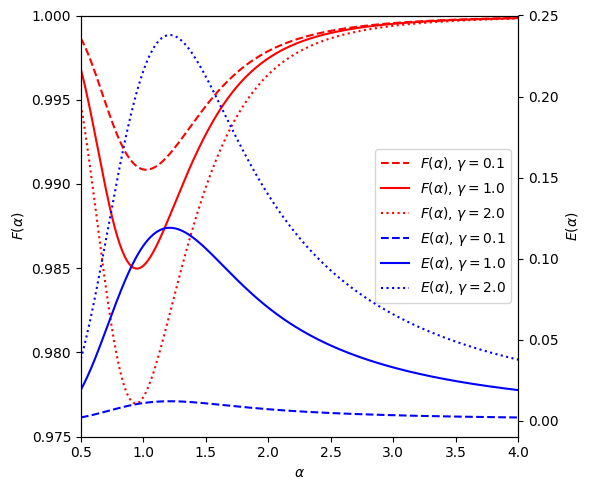

In [4]:
#parity +1
alphaspace = np.load('results/approx/alphaspace.npy')
alphaspace = -1j*alphaspace
gammaspace = np.load('results/approx/gammaspace.npy')

fig, axes = plt.subplots( figsize = (6,5))
axes2 = axes.twinx()


line = ['dashed','solid','dotted']
for i,gamma in enumerate(gammaspace):
    fidelity= np.load(f'results/approx/parity_plus/fidelity_{gamma}.npy')
    catability = np.load(f'results/approx/parity_plus/catability_{gamma}.npy')
    
    axes.plot(alphaspace,fidelity,linestyle = line[i], color = 'red',label =fr'$F(\alpha)$, $\gamma = {gamma}$')
    axes2.plot(alphaspace,catability,linestyle = line[i], color = 'blue',label = fr'$E(\alpha)$, $\gamma = {gamma}$')
    
axes.set_ylabel(r"$F(\alpha)$")
axes.set_xlabel(r"$\alpha$")
axes.set_ylim(0.975,1)
axes.set_xlim(0.5,4)

axes2.set_ylabel(r"$E(\alpha)$")
axes2.set_xlabel(r"$\alpha$")
axes2.set_ylim(-0.01,0.25)
lines1, labels1 = axes.get_legend_handles_labels()
lines2, labels2 = axes2.get_legend_handles_labels()

axes.legend(lines1 + lines2, labels1 + labels2, loc='center right')
plt.tight_layout()
plt.show()
fig.savefig('figs/benchmark_plus.svg')

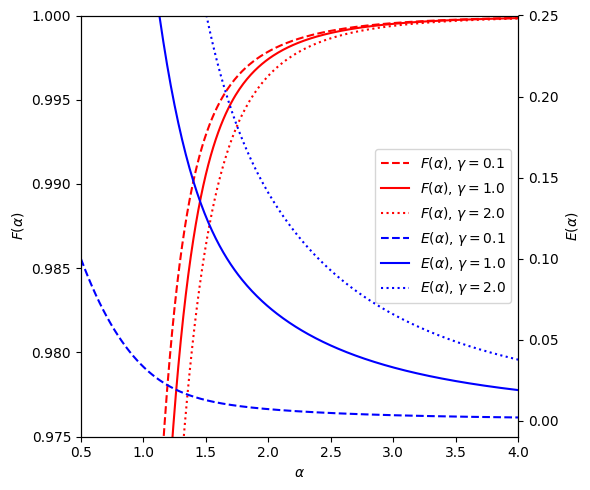

In [5]:
#parity -1
alphaspace = np.load('results/approx/alphaspace.npy')
alphaspace = -1j*alphaspace
gammaspace = np.load('results/approx/gammaspace.npy')

fig, axes = plt.subplots( figsize = (6,5))
axes2 = axes.twinx()

line = ['dashed','solid','dotted']
for i,gamma in enumerate(gammaspace):
    fidelity= np.load(f'results/approx/parity_minus/fidelity_{gamma}.npy')
    catability = np.load(f'results/approx/parity_minus/catability_{gamma}.npy')
    
    axes.plot(alphaspace,fidelity,linestyle = line[i], color = 'red',label =fr'$F(\alpha)$, $\gamma = {gamma}$')
    axes2.plot(alphaspace,catability,linestyle = line[i], color = 'blue',label = fr'$E(\alpha)$, $\gamma = {gamma}$')
    
axes.set_ylabel(r"$F(\alpha)$")
axes.set_xlabel(r"$\alpha$")
axes.set_ylim(0.975,1)
axes.set_xlim(0.5,4)

axes2.set_ylabel(r"$E(\alpha)$")
axes2.set_xlabel(r"$\alpha$")
axes2.set_ylim(-0.01,0.25)
lines1, labels1 = axes.get_legend_handles_labels()
lines2, labels2 = axes2.get_legend_handles_labels()

axes.legend(lines1 + lines2, labels1 + labels2, loc='center right')
plt.tight_layout()
plt.show()
fig.savefig('figs/benchmark_minus.svg')

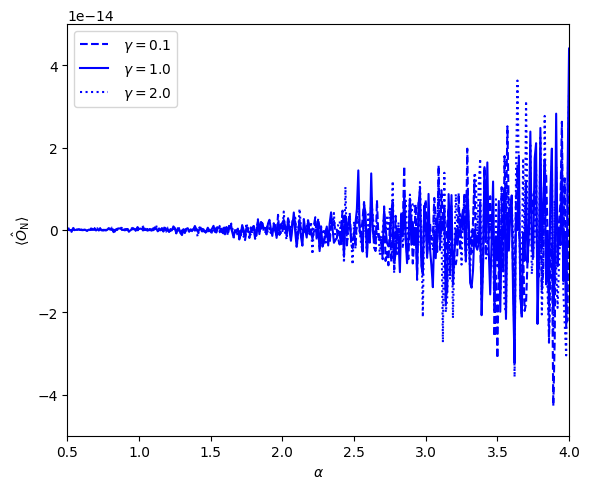

In [6]:
#normalized mean
#parity +1 
alphaspace = np.load('results/approx/alphaspace.npy')
alphaspace = -1j*alphaspace
gammaspace = np.load('results/approx/gammaspace.npy')

fig, axes = plt.subplots( figsize = (6,5))

line = ['dashed','solid','dotted']
for i,gamma in enumerate(gammaspace):
    catability = np.load(f'results/approx/parity_plus/catability_{gamma}_norm.npy')
    axes.plot(alphaspace,catability,linestyle = line[i], color = 'blue',label = fr' $\gamma = {gamma}$'
)

axes.set_ylabel(r"$\langle \hat{{O}}_{{\mathrm{{N}}}} \rangle$")
axes.set_xlabel(r"$\alpha$")
axes.set_ylim(-0.5e-13,0.5e-13)
axes.set_xlim(0.5,4)

lines1, labels1 = axes.get_legend_handles_labels()

axes.legend(loc='best')
plt.tight_layout()
plt.show()
fig.savefig('figs/benchmark_plus_norm.svg')

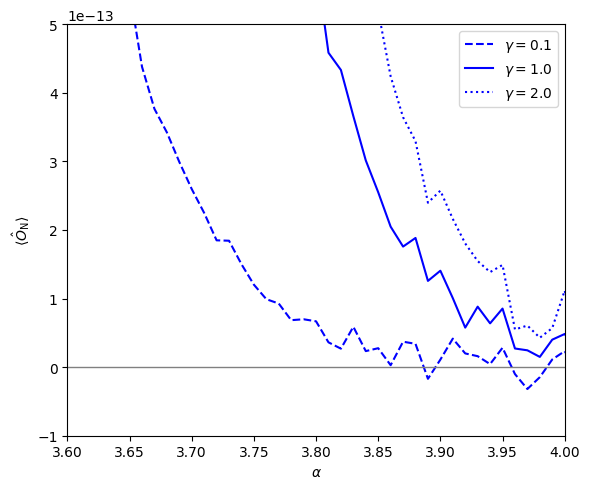

In [7]:
#normalized mean
#parity -1
alphaspace = np.load('results/approx/alphaspace.npy')
alphaspace = -1j*alphaspace
gammaspace = np.load('results/approx/gammaspace.npy')

fig, axes = plt.subplots( figsize = (6,5))

line = ['dashed','solid','dotted']
for i,gamma in enumerate(gammaspace):
    catability = np.load(f'results/approx/parity_minus/catability_{gamma}_norm.npy')
    catability = np.real(catability)
    axes.plot(alphaspace,catability,linestyle = line[i], color = 'blue',label = fr'$\gamma = {gamma}$'
)

axes.set_ylabel(r"$\langle \hat{{O}}_{{\mathrm{{N}}}} \rangle$")
axes.set_xlabel(r"$\alpha$")
axes.set_ylim(-0.1e-12,0.5e-12)
# axes.set_ylim(-0.00,0.25)
axes.set_xlim(3.6,4)
# axes.set_xlim(0.5,4)
axes.axhline(y=0.0, color='gray', linestyle='-', linewidth=1)

lines1, labels1 = axes.get_legend_handles_labels()

axes.legend(loc='best')
plt.tight_layout()
plt.show()
fig.savefig('figs/benchmark_minus_norm_detail.svg')